In [16]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

pkl_file = "data/MC_20260303_093108.pkl"
with open(pkl_file, "rb") as f:
    hist = pickle.load(f)

In [17]:
for k, v in hist.items():
    if isinstance(v, np.ndarray):
        print(f"{k}: ndarray shape={v.shape}")
    elif isinstance(v, list):
        print(f"{k}: list len={len(v)}")
    else:
        print(f"{k}: {type(v).__name__} = {v}")

obj_values: list len=30
power_values: list len=30
penalty_values: list len=30
params: list len=30
sim_geom: list len=30
gradients: list len=30
opt_states: list len=31
beta: list len=30
change: list len=30
ind_morph: list len=30


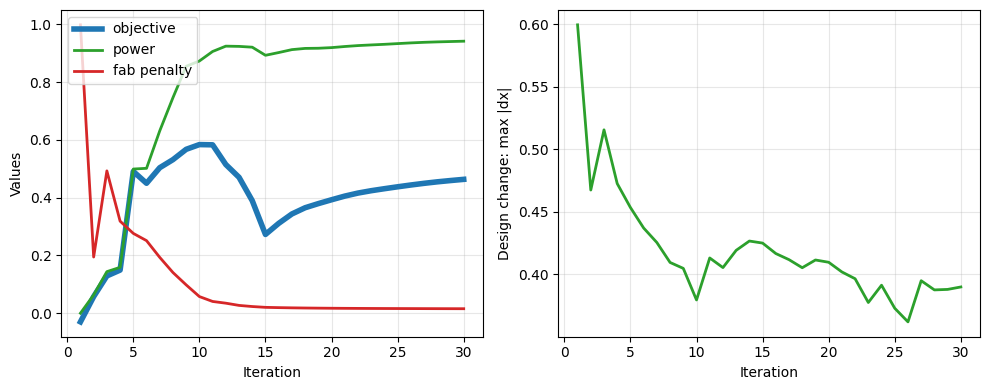

In [18]:
obj_values_hist = hist["obj_values"]
power_values_hist = hist["power_values"]
penalty_values_hist = hist["penalty_values"]
change_hist = hist["change"]
iters = np.arange(1, len(obj_values_hist) + 1)

fig_conv, axs_conv = plt.subplots(1, 2, figsize=(10, 4))

axs_conv[0].plot(iters, obj_values_hist, color="tab:blue", linewidth=4.0, label="objective")
axs_conv[0].plot(iters, power_values_hist, color="tab:green", linewidth=2.0, label="power")
axs_conv[0].plot(iters, penalty_values_hist, color="tab:red", linewidth=2.0, label="fab penalty")

axs_conv[0].set_xlabel("Iteration")
axs_conv[0].set_ylabel("Values")
axs_conv[0].grid(True, alpha=0.3)
axs_conv[0].legend()


axs_conv[1].plot(iters, change_hist, color="tab:green", linewidth=2.0)
axs_conv[1].set_xlabel("Iteration")
axs_conv[1].set_ylabel("Design change: max |dx|")
axs_conv[1].grid(True, alpha=0.3)
fig_conv.tight_layout()
plt.show()

In [19]:
import os
from PIL import Image
from pathlib import Path

timestamp = Path(pkl_file).stem
frame_dir = f"data/{timestamp}_frames"
os.makedirs(frame_dir, exist_ok=True)

sim_geom_all = np.array(hist["sim_geom"])

# Save each frame as PNG
frame_paths = []
for i, x in enumerate(sim_geom_all):
    fig, ax = plt.subplots()
    ax.imshow(1.0 - x.T, interpolation="none", origin="lower", cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Iteration {i+1}")
    ax.axis("off")
    fp = f"{frame_dir}/frame_{i:04d}.png"
    plt.savefig(fp, bbox_inches="tight", pad_inches=0, dpi=150)
    plt.close(fig)
    frame_paths.append(fp)

# Assemble GIF
frames = [Image.open(p) for p in frame_paths]
gif_path = f"{frame_dir}/{timestamp}.gif"
durations = [150] * len(frames)
durations[-1] = 1500  # last frame stays 1 second before looping
frames[0].save(gif_path, save_all=True, append_images=frames[1:],
               duration=durations, loop=0)
print(f"Saved GIF: {gif_path} ({len(frames)} frames)")

Saved GIF: data/MC_20260303_093108_frames/MC_20260303_093108.gif (30 frames)
